# Real World Dataset Analysis

using dataset "bob_ross_paintings.csv"

from https://github.com/jwilber/Bob_Ross_Paintings

In [294]:
# Import the necessary libraries and tools

import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt

In [295]:
# Read in the data
br_paint = pd.read_csv('bob_ross_paintings.csv')

In [296]:
# See info about each column
br_paint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        403 non-null    int64 
 1   painting_index    403 non-null    int64 
 2   img_src           403 non-null    object
 3   painting_title    403 non-null    object
 4   season            403 non-null    int64 
 5   episode           403 non-null    int64 
 6   num_colors        403 non-null    int64 
 7   youtube_src       403 non-null    object
 8   colors            403 non-null    object
 9   color_hex         403 non-null    object
 10  tags              403 non-null    object
 11  Black_Gesso       403 non-null    int64 
 12  Bright_Red        403 non-null    int64 
 13  Burnt_Umber       403 non-null    int64 
 14  Cadmium_Yellow    403 non-null    int64 
 15  Dark_Sienna       403 non-null    int64 
 16  Indian_Red        403 non-null    int64 
 17  Indian_Yellow   

In [297]:
# See how many columns and rows in the dataset
br_paint.shape

(403, 29)

In [298]:
# See the first 5 rows
br_paint.head

<bound method NDFrame.head of      Unnamed: 0  painting_index  \
0             1             282   
1             2             283   
2             3             284   
3             4             285   
4             5             286   
..          ...             ...   
398         399             407   
399         400             408   
400         401             409   
401         402             410   
402         403             411   

                                               img_src  \
0    https://www.twoinchbrush.com/images/painting28...   
1    https://www.twoinchbrush.com/images/painting28...   
2    https://www.twoinchbrush.com/images/painting28...   
3    https://www.twoinchbrush.com/images/painting28...   
4    https://www.twoinchbrush.com/images/painting28...   
..                                                 ...   
398  https://www.twoinchbrush.com/images/painting40...   
399  https://www.twoinchbrush.com/images/painting40...   
400  https://www.twoinchbru

In [299]:
# See the last 4 rows
br_paint.tail(4)

,Unnamed: 0,painting_index,img_src,painting_title,season,episode,num_colors,youtube_src,colors,color_hex,...,Liquid_Clear,Midnight_Black,Phthalo_Blue,Phthalo_Green,Prussian_Blue,Sap_Green,Titanium_White,Van_Dyke_Brown,Yellow_Ochre,Alizarin_Crimson
399,400,408,https://www.twoinchbrush.com/images/painting40...,Balmy Beach,31,10,13,https://www.youtube.com/embed/kMgd6r6c4vE,"['Alizarin Crimson', 'Black Gesso', 'Bright Re...","['#4E1500', '#000000', '#DB0000', '#FFEC00', '...",...,1,1,1,1,0,0,1,1,1,1
400,401,409,https://www.twoinchbrush.com/images/painting40...,Lake at the Ridge,31,11,12,https://www.youtube.com/embed/8QWvzEQ69Kw,"['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...","['#4E1500', '#DB0000', '#FFEC00', '#5F2E1F', '...",...,0,1,1,0,1,1,1,1,1,1
401,402,410,https://www.twoinchbrush.com/images/painting41...,In the Midst of Winter,31,12,7,https://www.youtube.com/embed/qx2IsmrCs3c,"['Alizarin Crimson', 'Dark Sienna', 'Midnight ...","['#4E1500', '#5F2E1F', '#000000', '#0C0040', '...",...,0,1,1,0,1,0,1,1,0,1
402,403,411,https://www.twoinchbrush.com/images/painting41...,Wilderness Day,31,13,12,https://www.youtube.com/embed/nJGCVFn57U8,"['Alizarin Crimson', 'Black Gesso', 'Bright Re...","['#4E1500', '#000000', '#DB0000', '#FFEC00', '...",...,0,1,1,0,0,1,1,1,1,1


In [300]:
# get stats
br_paint.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,403.0,202.000000,116.480327,1.0,101.5,202.0,302.5,403.0
painting_index,403.0,208.712159,117.901728,4.0,107.5,210.0,310.5,411.0
season,403.0,16.000000,8.955390,1.0,8.0,16.0,24.0,31.0
episode,403.0,7.000000,3.746308,1.0,4.0,7.0,10.0,13.0
num_colors,403.0,10.650124,2.388648,1.0,9.0,11.0,12.0,15.0
Black_Gesso,403.0,0.282878,0.450958,0.0,0.0,0.0,1.0,1.0
Bright_Red,403.0,0.796526,0.403082,0.0,1.0,1.0,1.0,1.0
Burnt_Umber,403.0,0.136476,0.343720,0.0,0.0,0.0,0.0,1.0
Cadmium_Yellow,403.0,0.858561,0.348907,0.0,1.0,1.0,1.0,1.0
Dark_Sienna,403.0,0.719603,0.449752,0.0,0.0,1.0,1.0,1.0


In [303]:
# Show the color names used in each painting
paintings = br_paint

color_names = (paintings["colors"].astype(str))

color_names["colors_list"] = paintings["colors"].loc(0)
color_names

0              ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
1              ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
2              ['Alizarin Crimson', 'Black Gesso', 'Bright Re...
3              ['Prussian Blue', 'Titanium White', 'Van Dyke ...
4              ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
                                     ...                        
399            ['Alizarin Crimson', 'Black Gesso', 'Bright Re...
400            ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
401            ['Alizarin Crimson', 'Dark Sienna', 'Midnight ...
402            ['Alizarin Crimson', 'Black Gesso', 'Bright Re...
colors_list    <pandas.core.indexing._LocIndexer object at 0x...
Name: colors, Length: 404, dtype: object

In [304]:
color_names["colors_list"] = br_paint["colors"].iloc(0)

# Count color NAME frequencies across all paintings ---
color_counts = Counter()
for lst in br_paint["colors_list"]:
    color_counts.update(lst)

color_freq = (pd.DataFrame(color_counts.items(), columns=["color", "Frequency of Color Use"])
      .sort_values("Frequency of Color Use", ascending=False)
      .reset_index(drop=True))

print(color_freq)

               color  Frequency of Color Use
0     Titanium White                     400
1   Alizarin Crimson                     380
2     Van Dyke Brown                     371
3     Cadmium Yellow                     346
4       Yellow Ochre                     327
5       Phthalo Blue                     323
6         Bright Red                     321
7     Midnight Black                     317
8          Sap Green                     306
9      Indian Yellow                     293
10       Dark Sienna                     290
11     Prussian Blue                     263
12     Phthalo Green                     116
13       Black Gesso                     114
14       Burnt Umber                      55
15      Liquid Clear                      51
16      Liquid Black                      19


In [305]:
# Colors used in Bob Ross paintings
color_names = (br_paint["colors"].astype(str))

color_names["colors_list"] = paintings["colors"].loc(0)
print (color_names)

0              ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
1              ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
2              ['Alizarin Crimson', 'Black Gesso', 'Bright Re...
3              ['Prussian Blue', 'Titanium White', 'Van Dyke ...
4              ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
                                     ...                        
399            ['Alizarin Crimson', 'Black Gesso', 'Bright Re...
400            ['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...
401            ['Alizarin Crimson', 'Dark Sienna', 'Midnight ...
402            ['Alizarin Crimson', 'Black Gesso', 'Bright Re...
colors_list    <pandas.core.indexing._LocIndexer object at 0x...
Name: colors, Length: 404, dtype: object


In [306]:
# How many seasons of Bob Ross Paintings exist
total_seasons = br_paint["season"].drop_duplicates()
total_seasons.count()
print("Total # of Seasons:", total_seasons.count())

Total # of Seasons: 31


In [307]:
# How many episodes of Bob Ross Paintings exist
episode_counts = br_paint["episode"]
print("Total # of Episodes:", episode_counts.count())

Total # of Episodes: 403


# In 403 episodes, how often was each color used?

In [309]:
col_sums = br_paint.sum(numeric_only=True, skipna=True)
col_sums

Unnamed: 0          81406
painting_index      84111
season               6448
episode              2821
num_colors           4292
Black_Gesso           114
Bright_Red            321
Burnt_Umber            55
Cadmium_Yellow        346
Dark_Sienna           290
Indian_Red              0
Indian_Yellow         293
Liquid_Black           19
Liquid_Clear           51
Midnight_Black        317
Phthalo_Blue          323
Phthalo_Green         116
Prussian_Blue         263
Sap_Green             306
Titanium_White        400
Van_Dyke_Brown        371
Yellow_Ochre          327
Alizarin_Crimson      380
dtype: int64

In [341]:
color_frequency = col_sums.drop(labels=["Unnamed: 0", "painting_index", "season", "episode", "num_colors"])
print("How often was each color used in 403 total episodes?")
print(color_frequency)

How often was each color used in 403 total episodes?
Black_Gesso         114
Bright_Red          321
Burnt_Umber          55
Cadmium_Yellow      346
Dark_Sienna         290
Indian_Red            0
Indian_Yellow       293
Liquid_Black         19
Liquid_Clear         51
Midnight_Black      317
Phthalo_Blue        323
Phthalo_Green       116
Prussian_Blue       263
Sap_Green           306
Titanium_White      400
Van_Dyke_Brown      371
Yellow_Ochre        327
Alizarin_Crimson    380
dtype: int64


In [359]:
# Colors used in Bob Ross' paintings and how often each color was used in 403 total episodes, sorted by most used
color_frequency = (pd.DataFrame(color_counts.items(), columns=["Color", "Frequency of Color Use"])
      .sort_values("Frequency of Color Use", ascending=False)
      .reset_index(drop=True))
print("Colors used in Bob Ross' paintings and how often each color was used in 403 total episodes, sorted by frequency")
print(color_frequency)

Colors used in Bob Ross' paintings and how often each color was used in 403 total episodes, sorted by frequency
               Color  Frequency of Color Use
0     Titanium White                     400
1   Alizarin Crimson                     380
2     Van Dyke Brown                     371
3     Cadmium Yellow                     346
4       Yellow Ochre                     327
5       Phthalo Blue                     323
6         Bright Red                     321
7     Midnight Black                     317
8          Sap Green                     306
9      Indian Yellow                     293
10       Dark Sienna                     290
11     Prussian Blue                     263
12     Phthalo Green                     116
13       Black Gesso                     114
14       Burnt Umber                      55
15      Liquid Clear                      51
16      Liquid Black                      19


In [361]:
top_color_frequency = (pd.DataFrame(color_counts.items(), columns=["Color", "Frequency of Color Use"])
                         .sort_values("Frequency of Color Use", ascending=False)
                         .reset_index(drop=True))

print("What were Bob Ross' top 5 colors used during 31 seasons (403 episodes) of 'The Joy of Painting' and how often was each color used?")
print(top_color_frequency.head(5).to_string(index=False))

What were Bob Ross' top 5 colors used during 31 seasons (403 episodes) of 'The Joy of Painting' and how often was each color used?
           Color  Frequency of Color Use
  Titanium White                     400
Alizarin Crimson                     380
  Van Dyke Brown                     371
  Cadmium Yellow                     346
    Yellow Ochre                     327


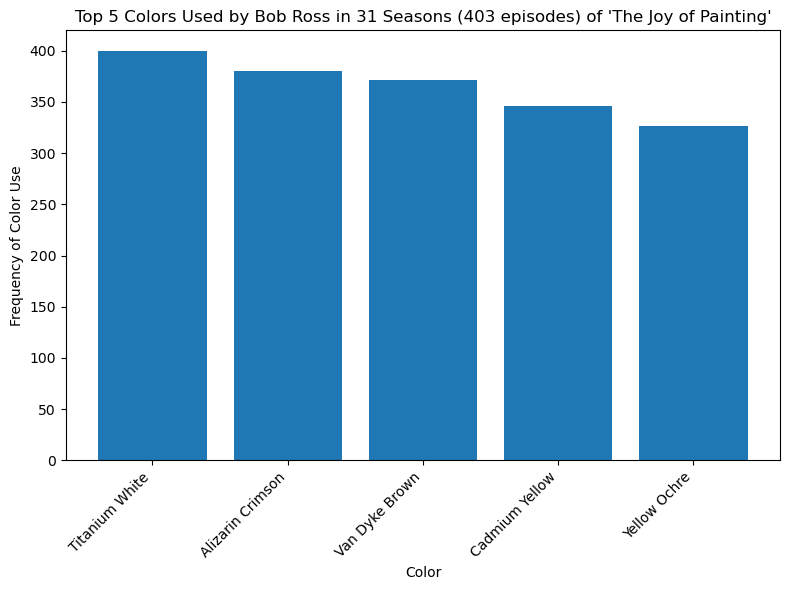

In [373]:
top5colors = top_color_frequency.head(5)

plt.figure(figsize=(8,6))
plt.bar(top5colors["Color"], top5colors["Frequency of Color Use"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Color")
plt.ylabel("Frequency of Color Use")
plt.title("Top 5 Colors Used by Bob Ross in 31 Seasons (403 episodes) of 'The Joy of Painting'")
plt.tight_layout()
plt.show()